In [ ]:
import numpy as np

import scipy.constants
from scipy.constants import hbar, pi, k, physical_constants
from scipy.optimize import root_scalar

amu = physical_constants["atomic mass constant"][0]  # kg
eV = physical_constants["electron volt"][0]          # J
angstrom = 1e-10                                     # m
kB_eV = k / eV                                       # eV/K
m_e_amu = scipy.constants.m_e / amu

class ParticleInBox1D_MetalUnits:
    def __init__(self, 
                 L_angstrom: float, 
                 m_amu: float=m_e_amu, 
                 eigen_N: int=100):
        self.L_m = L_angstrom * angstrom             # convert Å to m
        self.m = m_amu * amu                         # convert amu to kg
        self.eigen_N = eigen_N
        self.eigen_n = np.arange(1, eigen_N + 1)
        self.eigen_E = (hbar**2 * pi**2 * self.eigen_n**2)\
             / (2 * self.m * self.L_m**2) / eV  # eV

    def eigen_psi(self, 
            eigen_n: int, 
            x_angstrom: np.ndarray):
        x = x_angstrom * angstrom
        return np.sqrt(2 / self.L_m) * np.sin(eigen_n * pi * x / self.L_m)

    def fermi_dirac(self, T, mu):
        beta = 1 / (kB_eV * T)
        x = (self.eigen_E - mu) * beta
        x = np.clip(x, -100, 100)
        return 1.0 / (np.exp(x) + 1)

    def total_particles(self, T, mu):
        return 2 * np.sum(self.fermi_dirac(T, mu))

    def total_energy(self, T, mu):
        f = self.fermi_dirac(T, mu)
        return 2 * np.sum(f * self.eigen_E)

    def find_chemical_potential(self, T, N_target):
        def f(mu):
            return self.total_particles(T, mu) - N_target
        mu_min = self.eigen_E[0] - 1
        mu_max = self.eigen_E[-1] + 1
        sol = root_scalar(f, bracket=[mu_min, mu_max])
        return sol.root


In [31]:
box = ParticleInBox1D_MetalUnits(L_angstrom=10.0, m_amu=1.0, eigen_N=100)  # hydrogen in 10 Å box
print(f"\t.eigen_E.shape:{box.eigen_E.shape}")
N = 20
T = 300

E_fermi = box.eigen_E[N // 2 - 1]
mu = box.find_chemical_potential(T, N)

print(f"Fermi energy at T=0K: {E_F:.3f} eV")
print(f"Chemical potential at T=300K: {mu:.3f} eV")


	.eigen_E.shape:(100,)
Fermi energy at T=0K: 0.021 eV
Chemical potential at T=300K: 0.027 eV


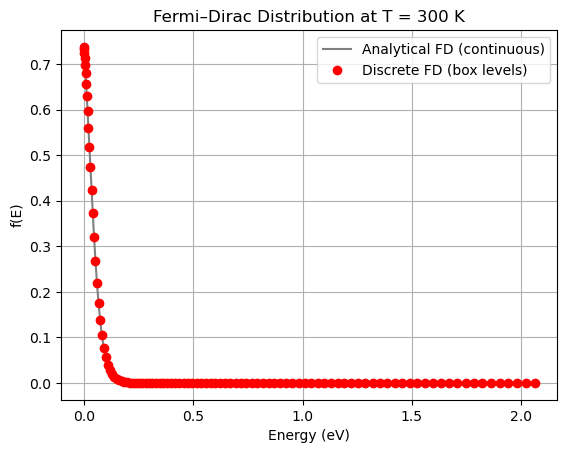

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k, e

def fermi_dirac_continuous(E, mu, T):
    """Analytical Fermi–Dirac distribution (E in eV)"""
    kT = k * T / e  # eV
    x = (E - mu) / kT
    x = np.clip(x, -100, 100)  # prevent overflow
    return 1.0 / (np.exp(x) + 1)

# From your discrete model
E_n = box.eigen_E
f_n = box.fermi_dirac(T, mu)

# Define fine-grained continuous energy range
E_cont = np.linspace(min(E_n), max(E_n), 1000)
f_cont = fermi_dirac_continuous(E_cont, mu, T)

# Plot comparison
plt.plot(E_cont, f_cont, label='Analytical FD (continuous)', color='gray')
plt.plot(E_n, f_n, 'o', label='Discrete FD (box levels)', color='red')
plt.xlabel('Energy (eV)')
plt.ylabel('f(E)')
plt.title(f'Fermi–Dirac Distribution at T = {T} K')
plt.legend()
plt.grid(True)
plt.show()
